In [1]:
import numpy as np
import copy
import math

In [2]:
xT_grid = np.array([
[0.006,0.007,0.008,0.009,0.010,0.011,0.012,0.013,0.014,0.016,0.018,0.021,0.024,0.028,0.033,0.039],
[0.007,0.008,0.009,0.010,0.012,0.013,0.014,0.016,0.018,0.020,0.023,0.027,0.031,0.037,0.044,0.052],
[0.008,0.009,0.011,0.012,0.014,0.016,0.018,0.020,0.023,0.026,0.030,0.035,0.041,0.048,0.057,0.067],
[0.009,0.011,0.012,0.014,0.016,0.018,0.021,0.024,0.027,0.031,0.036,0.042,0.049,0.058,0.069,0.081],
[0.010,0.012,0.014,0.016,0.018,0.021,0.024,0.027,0.031,0.036,0.042,0.049,0.057,0.067,0.079,0.093],
[0.011,0.013,0.016,0.018,0.021,0.024,0.027,0.031,0.036,0.042,0.049,0.057,0.067,0.079,0.093,0.110],
[0.011,0.013,0.016,0.018,0.021,0.024,0.027,0.031,0.036,0.042,0.049,0.057,0.067,0.079,0.093,0.110],
[0.010,0.012,0.014,0.016,0.018,0.021,0.024,0.027,0.031,0.036,0.042,0.049,0.057,0.067,0.079,0.093],
[0.009,0.011,0.012,0.014,0.016,0.018,0.021,0.024,0.027,0.031,0.036,0.042,0.049,0.058,0.069,0.081],
[0.008,0.009,0.011,0.012,0.014,0.016,0.018,0.020,0.023,0.026,0.030,0.035,0.041,0.048,0.057,0.067],
[0.007,0.008,0.009,0.010,0.012,0.013,0.014,0.016,0.018,0.020,0.023,0.027,0.031,0.037,0.044,0.052],
[0.006,0.007,0.008,0.009,0.010,0.011,0.012,0.013,0.014,0.016,0.018,0.021,0.024,0.028,0.033,0.039]
])
def getxT(x1,y1):
    return float(xT_grid[y1//4][x1//4])

def xTDiff(x1,y1,x2,y2):
    return float(getxT(x2,y2) - getxT(x1,y1))

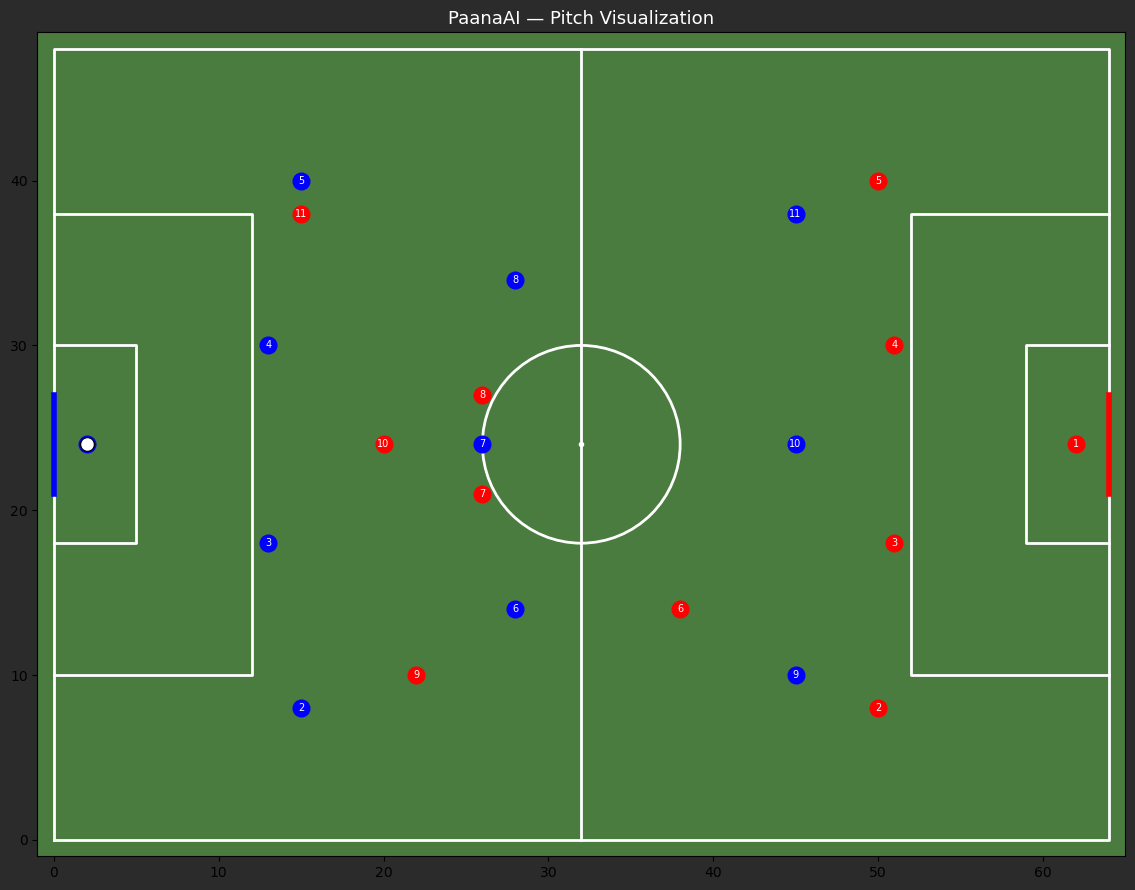

43.0

In [3]:
import matplotlib.pyplot as plt

def draw_pitch(ax):
    ax.set_facecolor('#4a7c3f')
    ax.plot([0,64,64,0,0], [0,0,48,48,0], color='white', linewidth=2)
    ax.plot([32,32], [0,48], color='white', linewidth=2)
    center_circle = plt.Circle((32,24), 6, color='white', fill=False, linewidth=2)
    ax.add_patch(center_circle)
    ax.plot(32, 24, 'o', color='white', markersize=3)
    ax.plot([0,12,12,0], [10,10,38,38], color='white', linewidth=2)
    ax.plot([0,5,5,0], [18,18,30,30], color='white', linewidth=2)
    ax.plot([0,0], [21,27], color='blue', linewidth=4)
    ax.plot([64,52,52,64], [10,10,38,38], color='white', linewidth=2)
    ax.plot([64,59,59,64], [18,18,30,30], color='white', linewidth=2)
    ax.plot([64,64], [21,27], color='red', linewidth=4)

def visualize(team_a, team_b, ball):
    fig, ax = plt.subplots(figsize=(12, 9))
    draw_pitch(ax)

    for i, (x, y) in enumerate(team_b):
        ax.plot(x, y, 'o', color='red', markersize=12, zorder=5)
        ax.text(x, y, str(i+1), color='white', fontsize=7, ha='center', va='center', zorder=6)

    for i, (x, y) in enumerate(team_a):
        ax.plot(x, y, 'o', color='blue', markersize=12, zorder=5)
        ax.text(x, y, str(i+1), color='white', fontsize=7, ha='center', va='center', zorder=6)

    bx, by = ball
    ax.plot(bx, by, 'o', color='white', markersize=10, markeredgecolor='black', zorder=7)

    ax.set_xlim(-1, 65)
    ax.set_ylim(-1, 49)
    ax.set_aspect('equal')
    ax.set_title('PaanaAI — Pitch Visualization', color='white', fontsize=13)
    fig.patch.set_facecolor('#2b2b2b')

    plt.tight_layout()
    plt.show()


# --- Test ---
# Team A (blue) — attacking right, goalkeeper on left
team_a = [
    (2, 24),   # 1. Goalkeeper
    (15, 8),   # 2. Right Back
    (13, 18),  # 3. Center Back
    (13, 30),  # 4. Center Back
    (15, 40),  # 5. Left Back
    (28, 14),  # 6. Right Midfielder
    (26, 24),  # 7. Central Midfielder
    (28, 34),  # 8. Left Midfielder
    (45, 10),  # 9. Right Winger
    (45, 24),  # 10. Striker
    (45, 38),  # 11. Left Winger
]

# Team B (red) — attacking left, goalkeeper on right
team_b = [
    (62, 24),  # 1. Goalkeeper
    (50, 8),   # 2. Left Back (their right back)
    (51, 18),  # 3. Center Back
    (51, 30),  # 4. Center Back
    (50, 40),  # 5. Right Back
    (38, 14),  # 6. Left Midfielder
    (26, 21),  # 7. Central Midfielder
    (26, 27),  # 8. Right Midfielder
    (22, 10),  # 9. Left Winger
    (20, 24),  # 10. Striker
    (15, 38),  # 11. Right Winger
]

ball = copy.deepcopy(team_a[0])  # ball at team_a's central midfielder

visualize(team_a, team_b, ball)

math.dist(team_a[0], team_a[9])

In [6]:
def getOffsideLine(team_b):
    maxi = float('-inf')
    maxi2 = float('-inf')
    for dx, dy in team_b:
        if dx > maxi:
            maxi2 = maxi
            maxi = dx
        elif dx > maxi2:
            maxi2 = dx
    return maxi2

def getAngle(ox, oy, nx, ny, dx, dy):
    pass_angle = math.degrees(math.atan2(ny-oy, nx-ox))
    def_angle  = math.degrees(math.atan2(dy-oy, dx-ox))
    diff = (def_angle - pass_angle + 180) % 360 - 180
    return diff

def getConeAngle(distance):
    if distance < 10:
        return 4
    elif distance < 20:
        return 5
    else:
        return 6

def getReceiverRisk(nx, ny, team_b, distance):
    risk = 0
    radius = distance * 0.3
    for dx, dy in team_b:
        dist = math.dist((dx,dy),(nx,ny))
        if dist <= radius * 0.125: risk += 8
        elif dist <= radius * 0.25: risk += 4
        elif dist <= radius * 0.5:  risk += 2
        elif dist <= radius:        risk += 1
        elif dist <= radius * 2:    risk += 0.5
        elif dist <= radius * 4:    risk += 0.25
        elif dist <= radius * 8:    risk += 0.125
    return risk

def getRisk(ox, oy, nx, ny, team_b):
    distance = math.dist((ox,oy),(nx,ny))
    cone_angle = getConeAngle(distance)
    interceptor_in_lane = False
    for dx, dy in team_b:
        def_dist = math.dist((ox,oy),(dx,dy))
        if def_dist >= distance:
            continue
        angle_diff = getAngle(ox, oy, nx, ny, dx, dy)
        if abs(angle_diff) <= cone_angle:
            interceptor_in_lane = True
            break
    risk = 0
    if interceptor_in_lane: # lofted pass
        risk += getReceiverRisk(nx, ny, team_b, distance + distance/20)
        risk += distance * 0.05
    else: # ground pass
        risk += getReceiverRisk(nx, ny, team_b,distance)
    pass_type = "lofted"if interceptor_in_lane else "ground"
    return risk, pass_type

def getBestPass(ball,team_a,team_b,mode):
    offside_line = getOffsideLine(team_b)
    maxTD = 0.110 - 0.006
    maxRisk = 30
    x, y = ball
    maxi = float('-inf')
    bestpass = -1
    xf,yf = 0, 0
    Type = 0
    if not mode:
        xf, yf = 0.2, 0.8
    elif mode == 1:
        xf, yf = 0.35, 0.7
    elif mode == 2:
        xf, yf = 0.5, 0.5
    elif mode == 3:
        xf, yf = 0.65, 0.3
    elif mode == 4:
        xf, yf = 0.8, 0.2
    i = 0
    num = -1
    for dx, dy in team_a:
        i+=1
        if dx > max(offside_line,x):
            continue
        if math.dist((x,y),(dx,dy)) > 45:
            continue
        xTD = xTDiff(x,y,dx,dy)
        risk, ttype = getRisk(x,y,dx,dy,team_b)
        risk = risk/maxRisk
        xTD = xTD/maxTD
        res = xTD * xf - risk * yf
        if res > maxi:
            maxi = res
            bestpass = (dx,dy)
            Type = ttype
            num = i
    if bestpass == ball or bestpass == -1:
        if math.dist((64,24),ball) < 10:
            print('Go for a Shot')
        else:
            print('Keep the ball')
    else:
        print(f'Best pass is to number: {num}\nPass type: {Type}')

In [7]:
getBestPass(ball,team_a,team_b,0)

Keep the ball
